In [ ]:
!pip install petsc4py

In [4]:
import petsc4py
from petsc4py import PETSc
import numpy as np



RICHARDSON + NONE         :  Not Converged      2 iterations, time = 0.0005s
RICHARDSON + JACOBI       :  Not Converged    200 iterations, time = 0.0195s
RICHARDSON + SOR          :  Converged        200 iterations, time = 0.0407s
RICHARDSON + ILU          :  Not Converged    200 iterations, time = 0.0414s
CHEBYSHEV + NONE          :  Not Converged      3 iterations, time = 0.0039s
CHEBYSHEV + JACOBI        :  Not Converged    200 iterations, time = 0.0350s
CHEBYSHEV + SOR           :  Not Converged    200 iterations, time = 0.0820s
CHEBYSHEV + ILU           :  Not Converged    200 iterations, time = 0.0639s
CG + NONE                 :  Not Converged      2 iterations, time = 0.0003s
CG + JACOBI               :  Not Converged      2 iterations, time = 0.0004s
CG + SOR                  :  Not Converged      2 iterations, time = 0.0006s
CG + ILU                  :  Not Converged      2 iterations, time = 0.0019s
BICG + NONE               :  Not Converged      1 iterations, time = 0.0007s

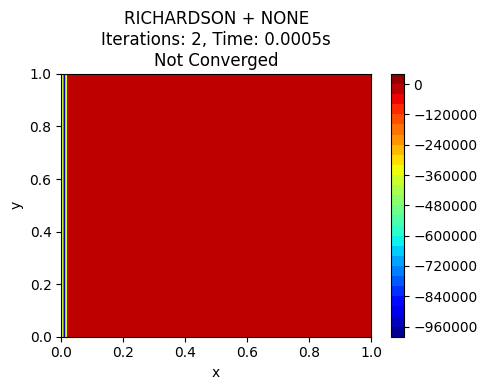

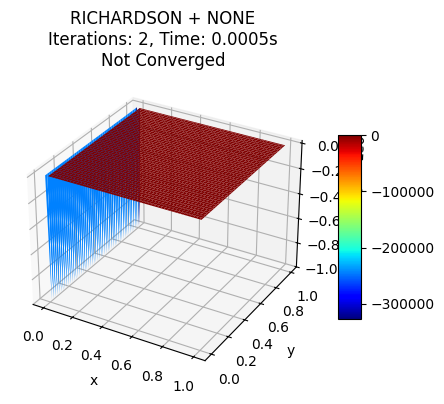

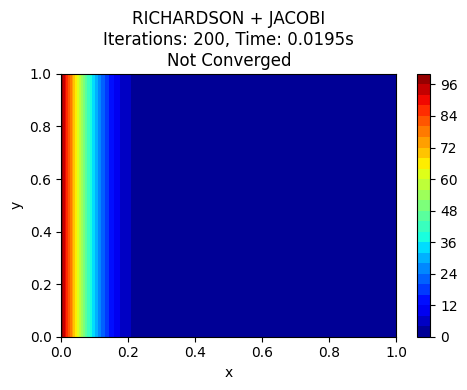

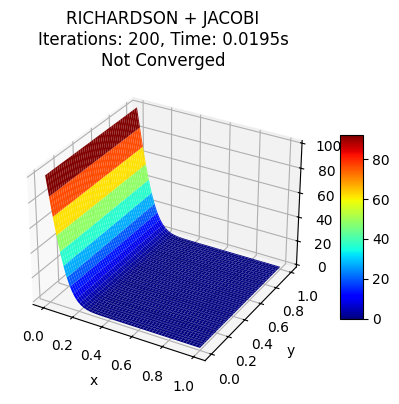

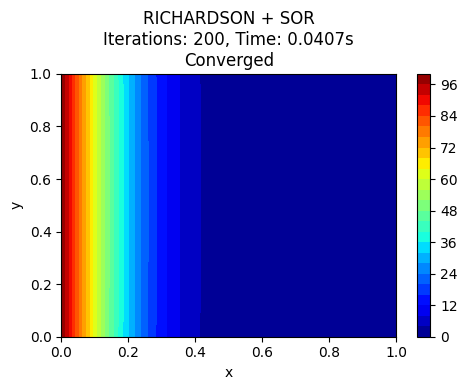

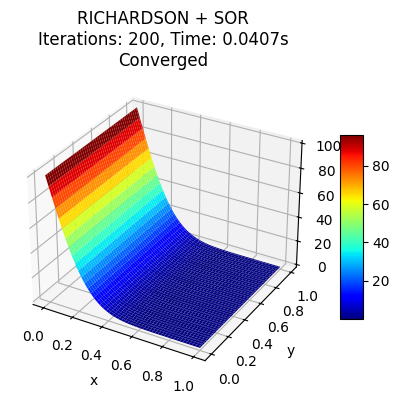

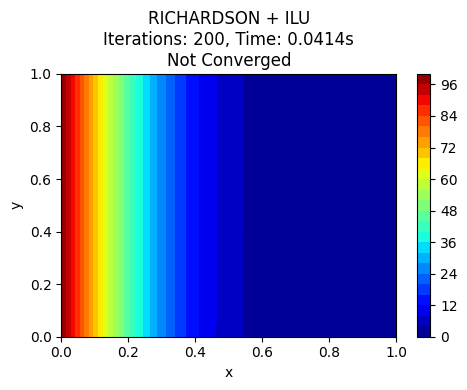

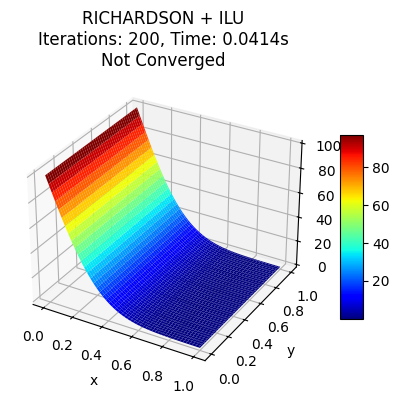

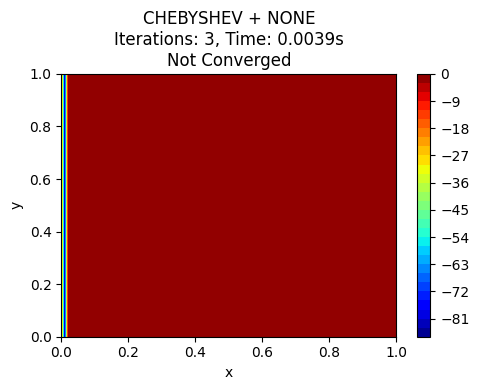

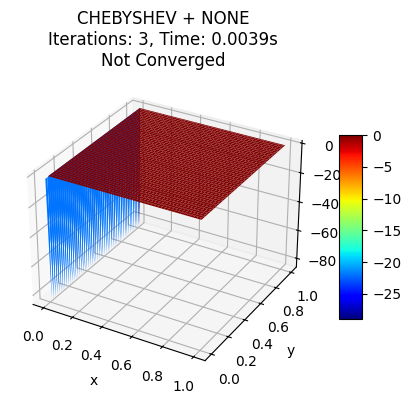

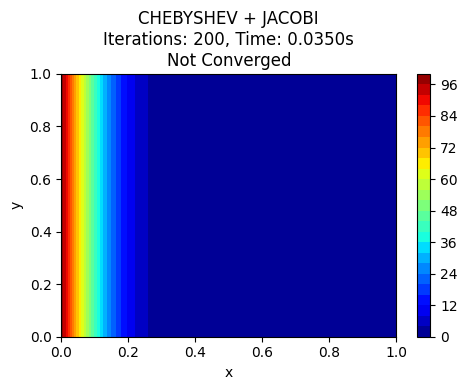

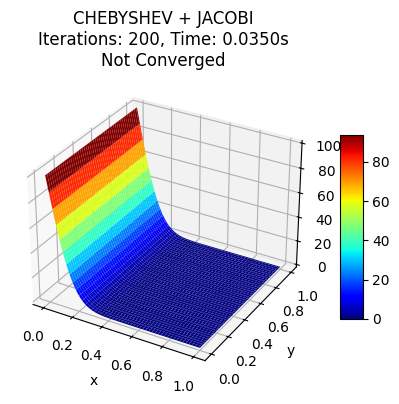

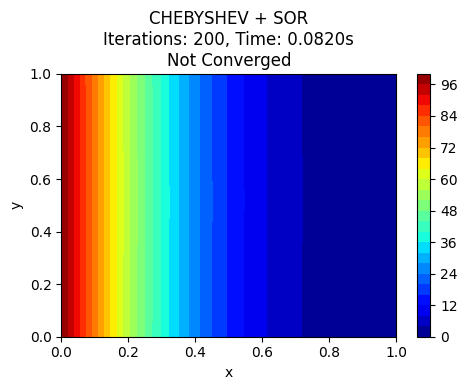

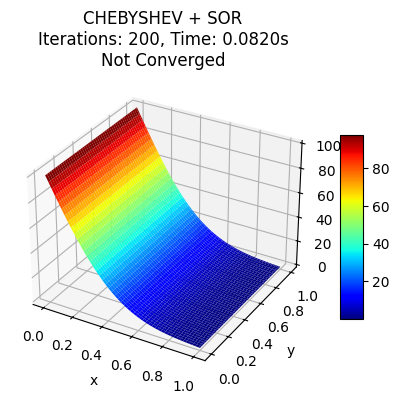

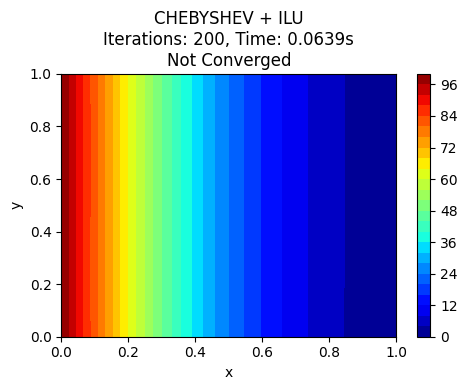

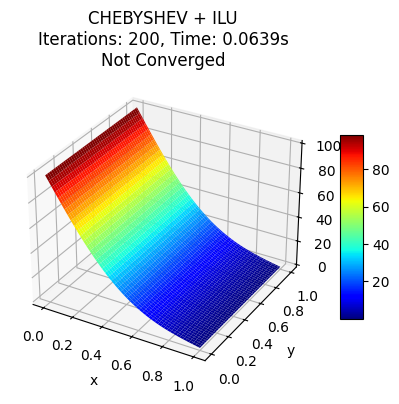

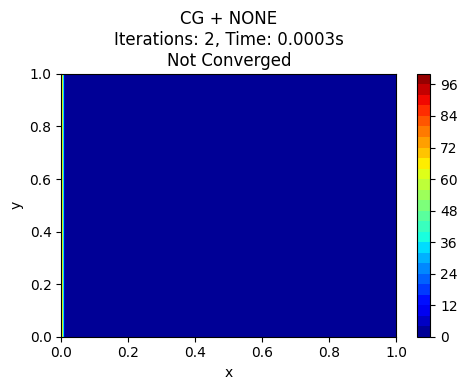

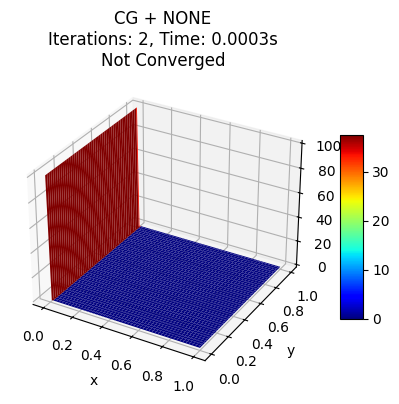

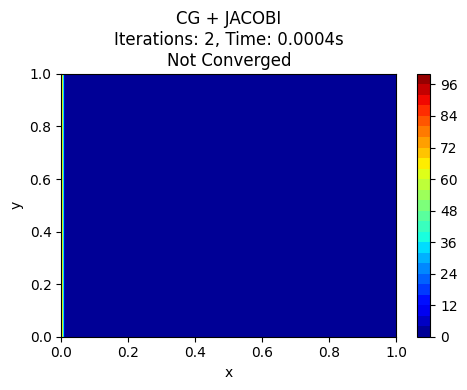

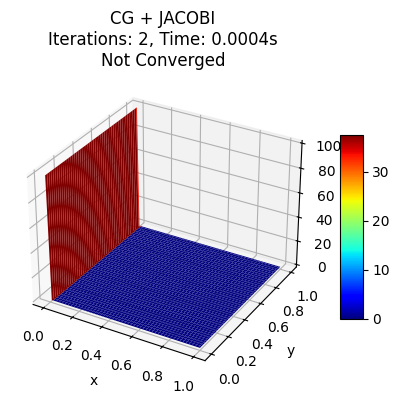

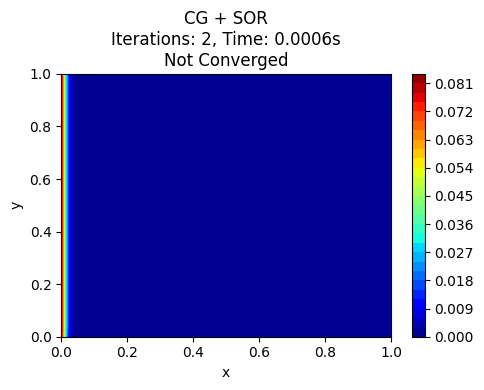

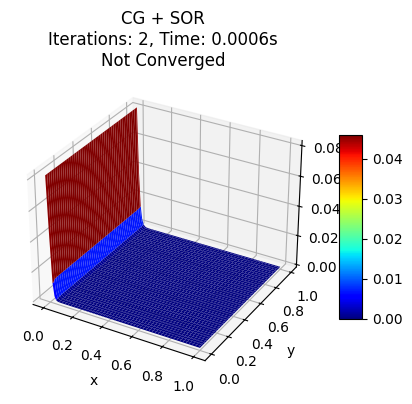

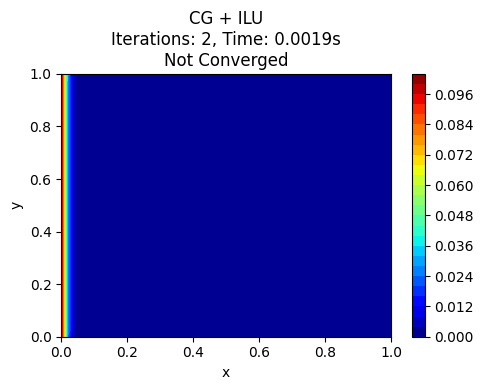

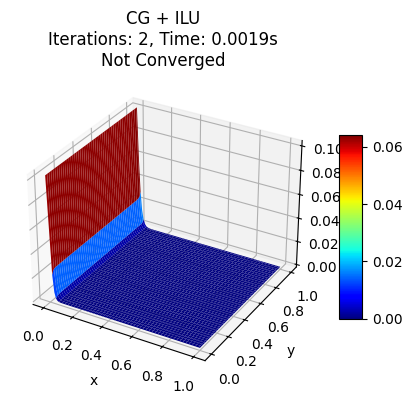

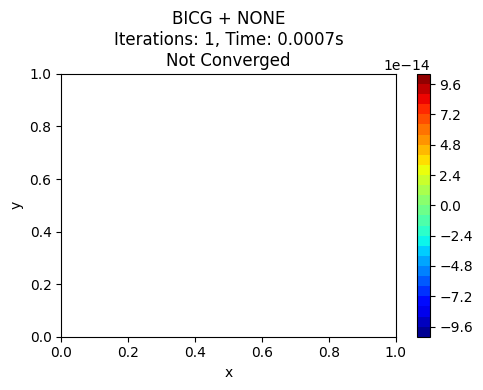

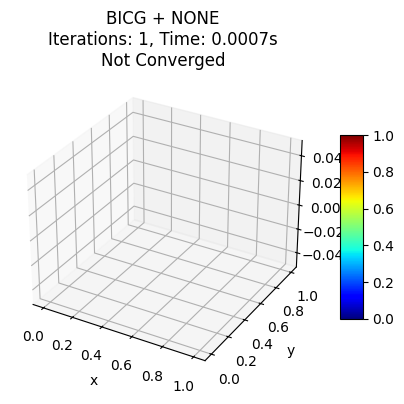

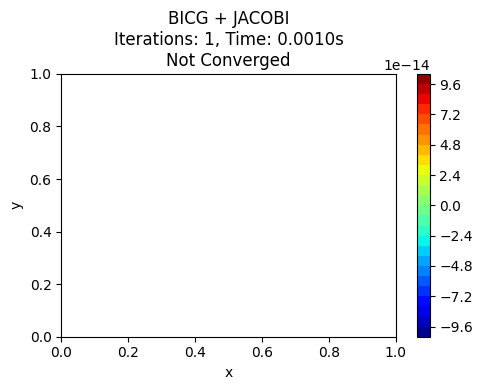

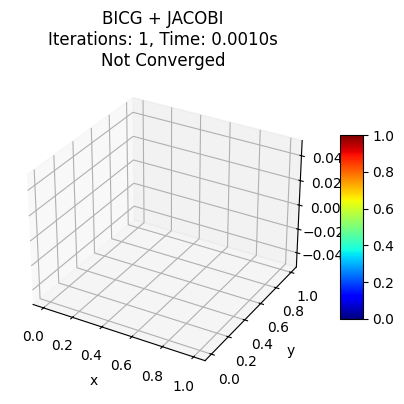

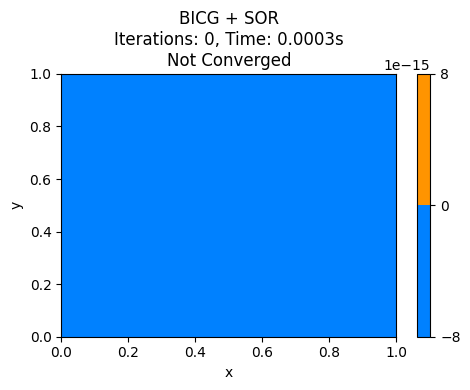

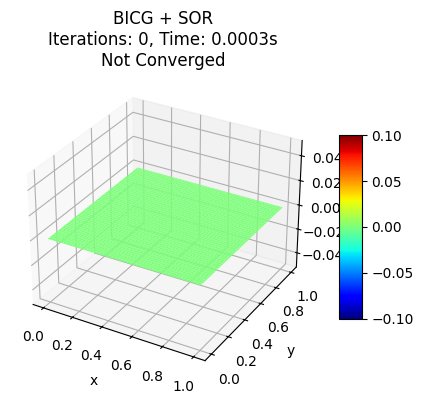

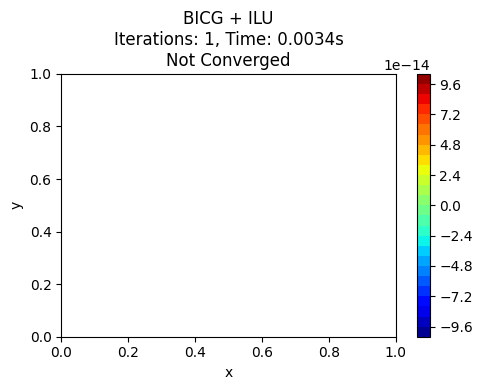

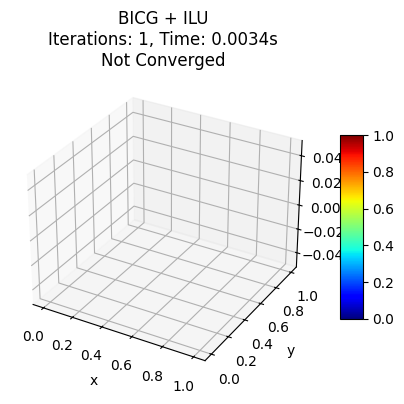

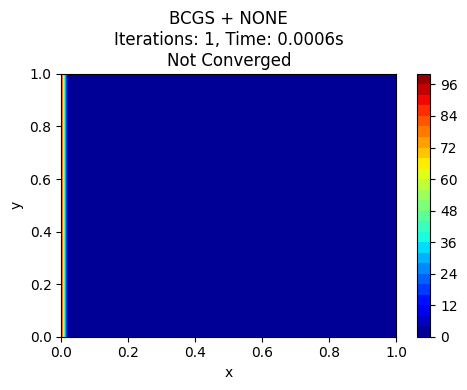

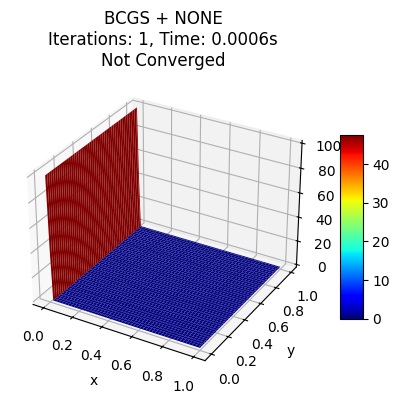

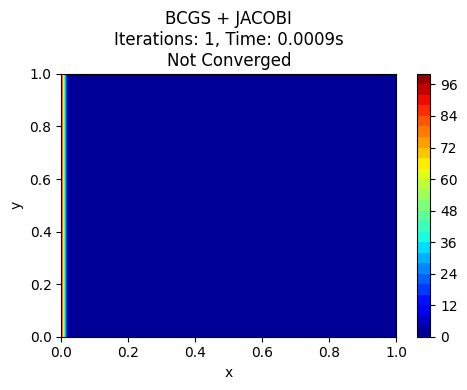

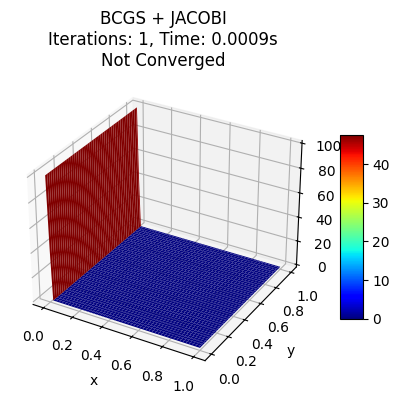

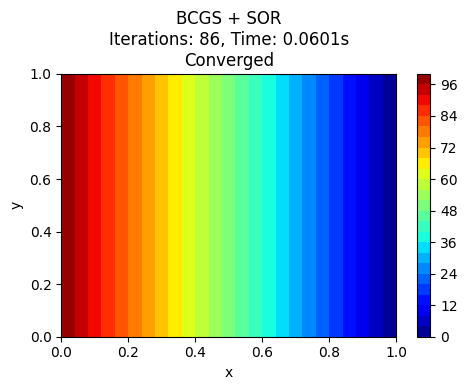

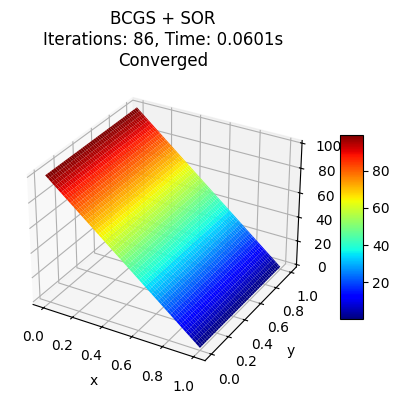

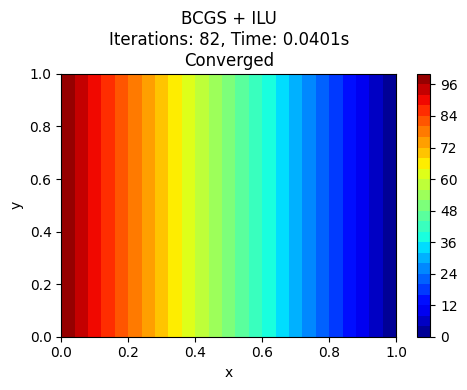

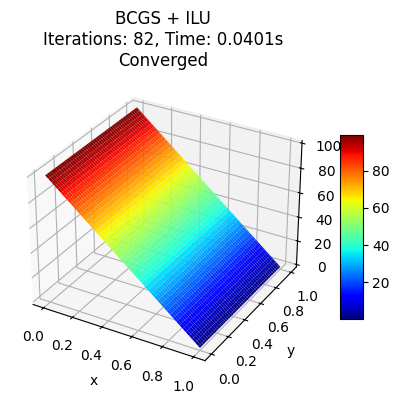

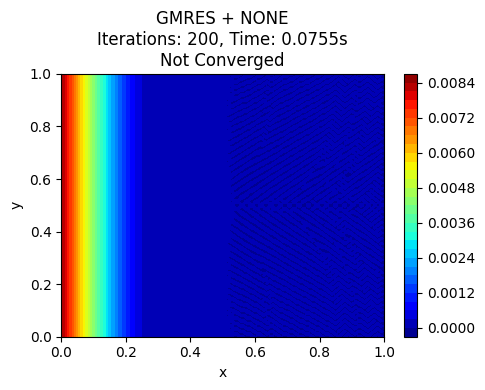

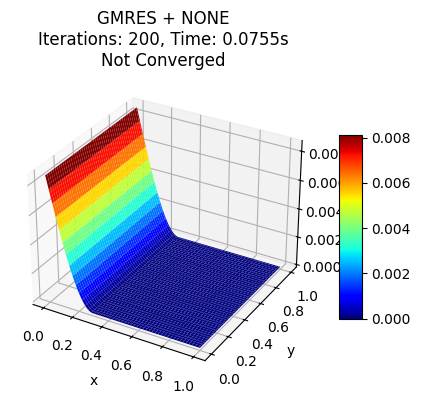

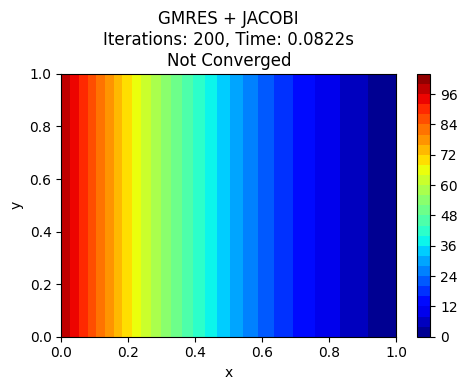

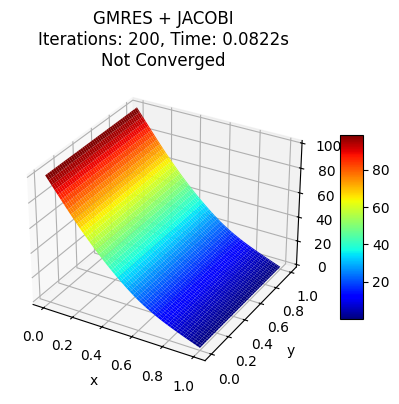

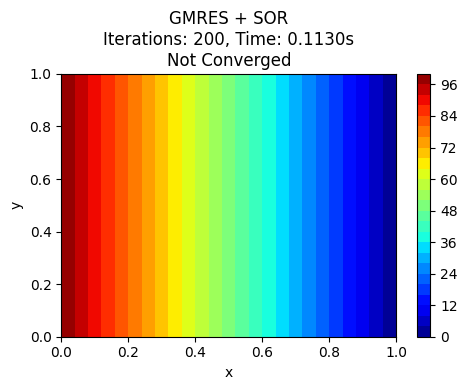

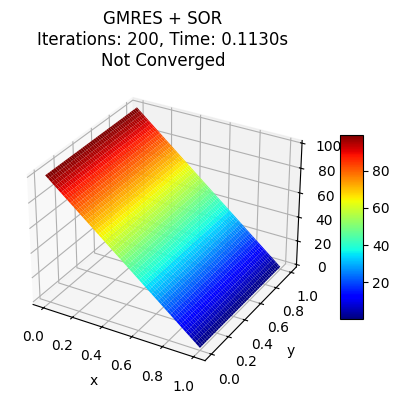

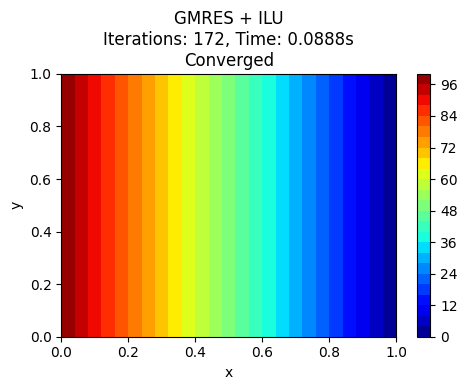

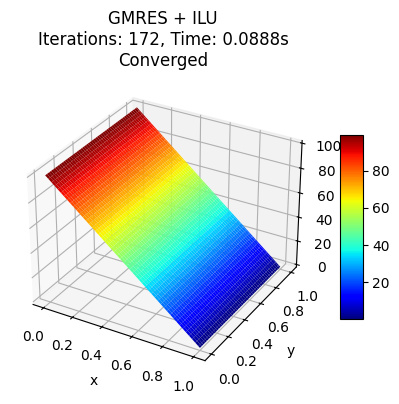

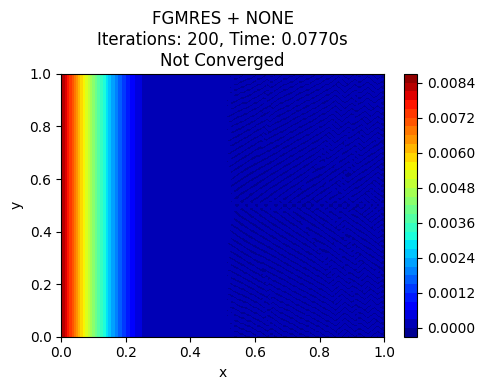

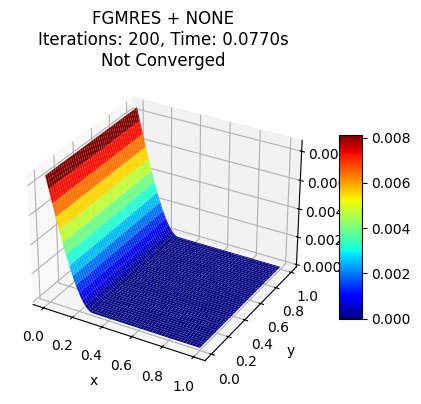

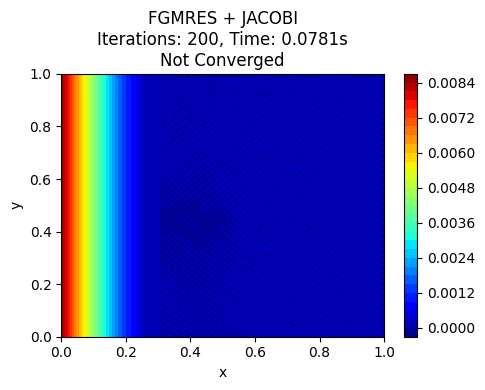

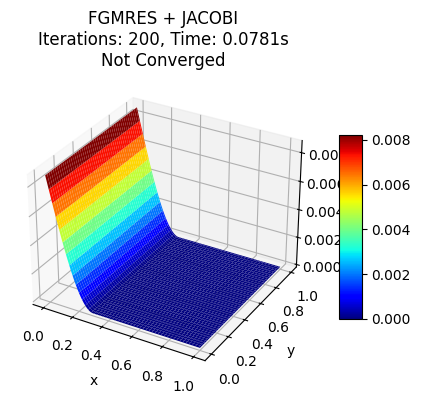

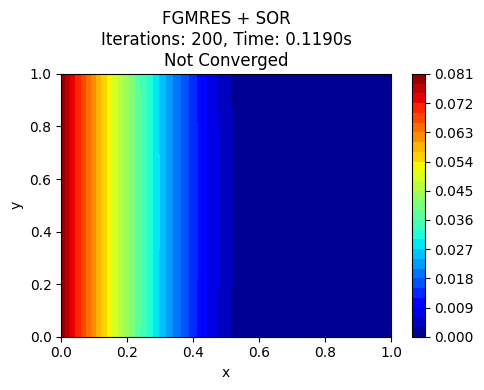

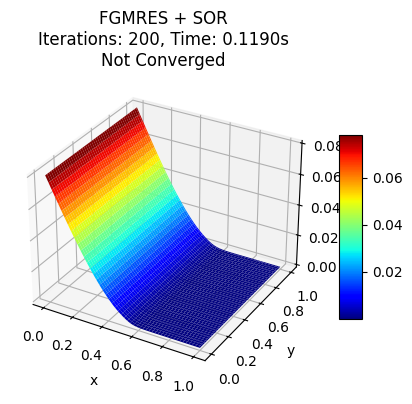

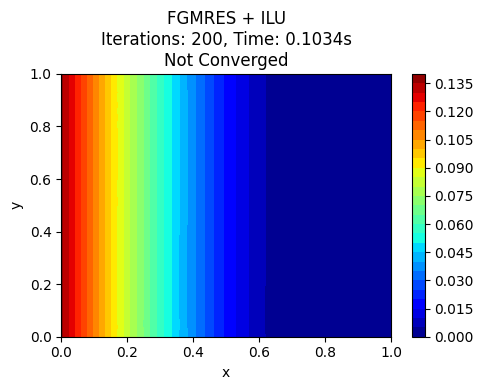

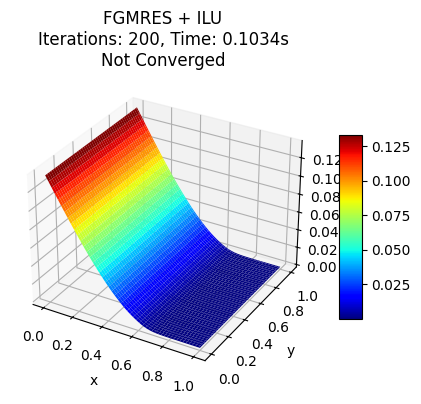

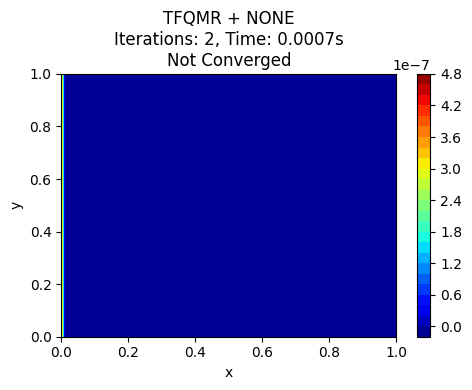

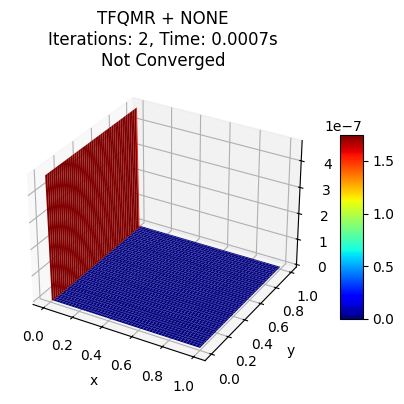

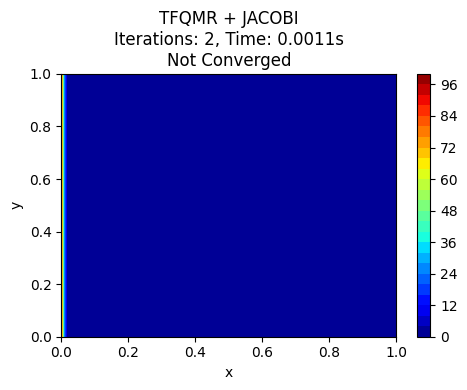

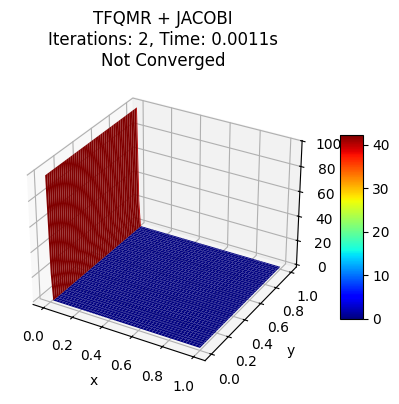

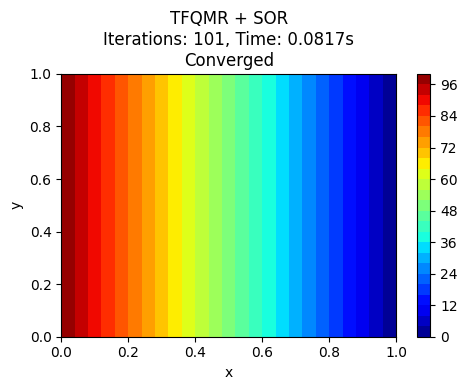

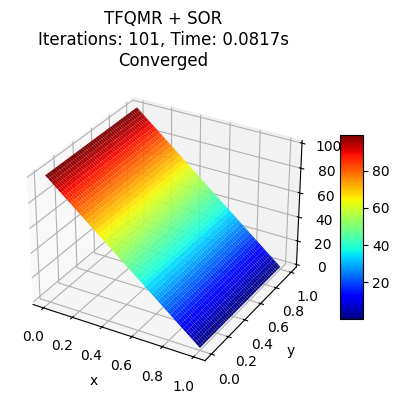

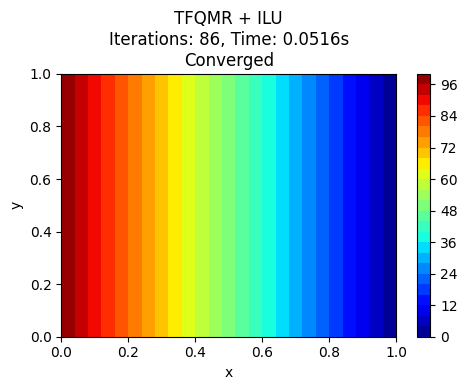

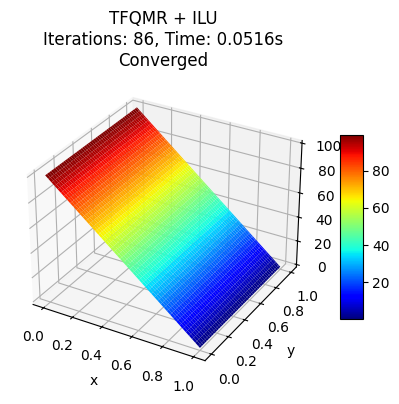

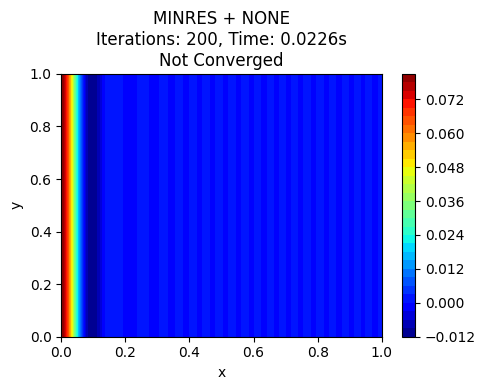

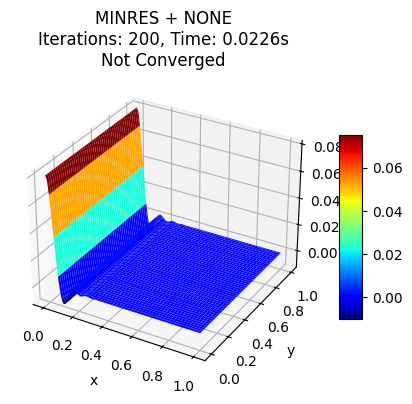

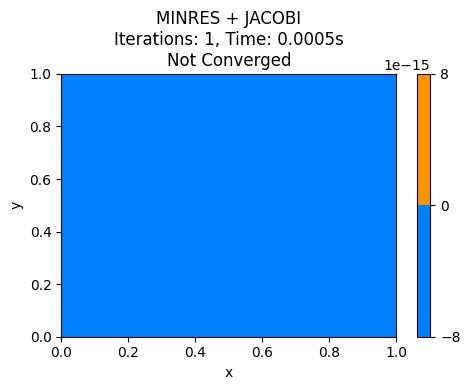

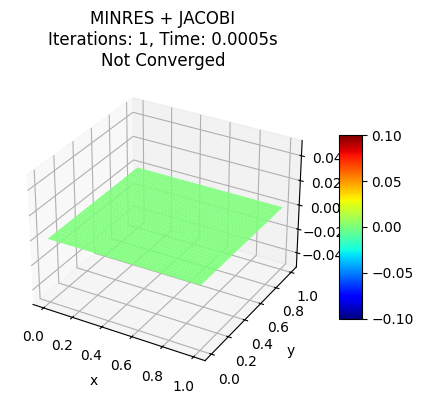

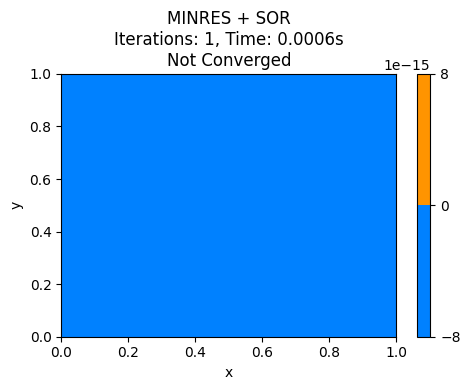

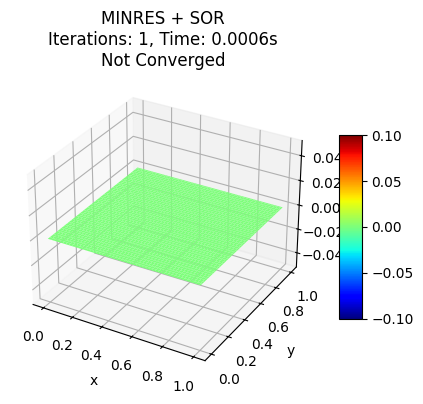

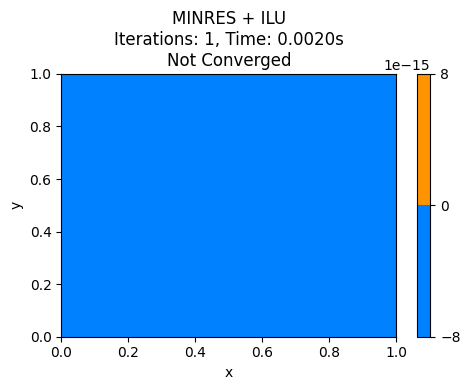

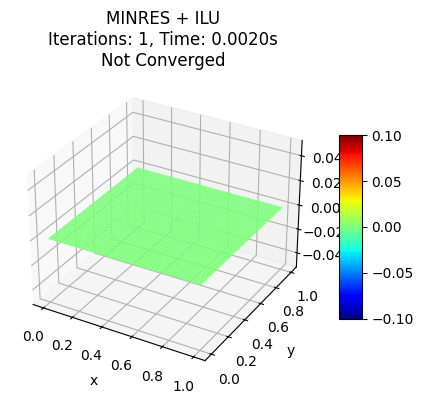

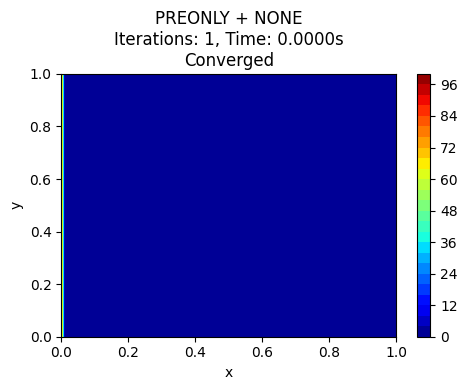

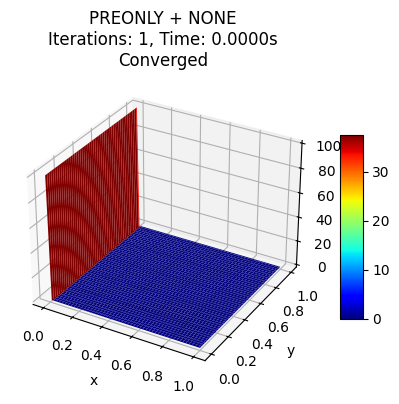

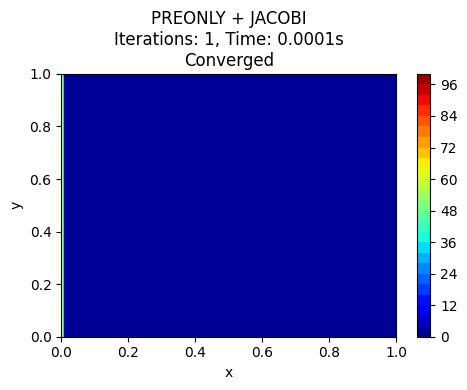

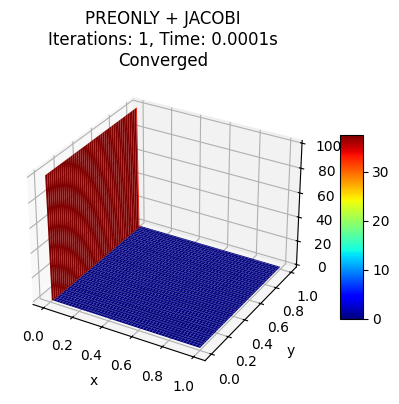

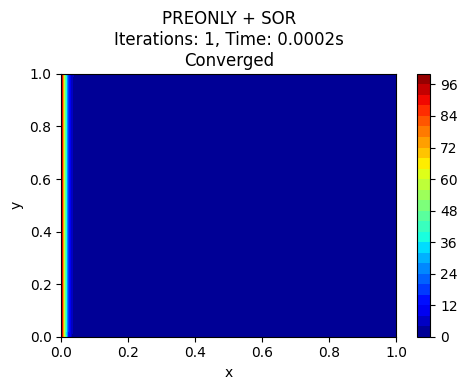

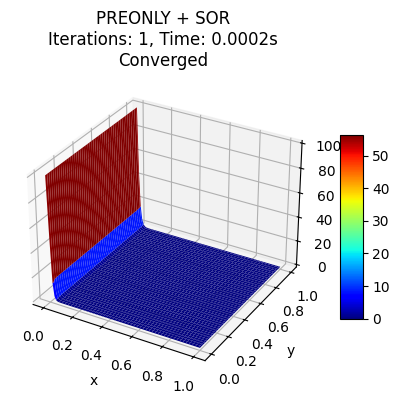

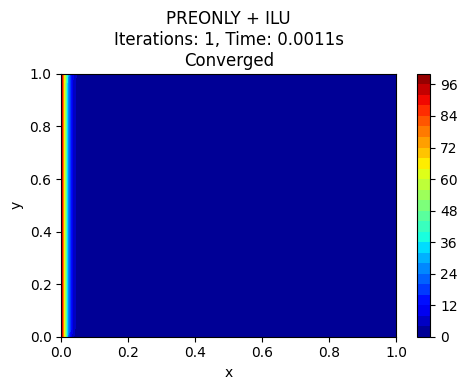

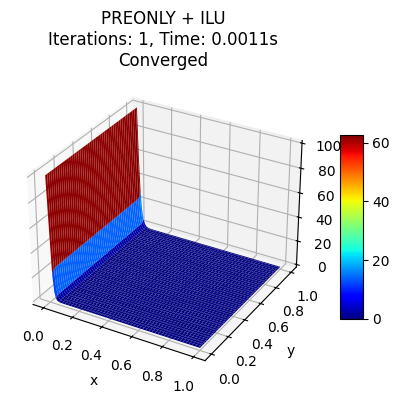

In [20]:
import numpy as np
from petsc4py import PETSc
import matplotlib.pyplot as plt
import time
from mpl_toolkits.mplot3d import Axes3D

# Domain and grid
Lx, Ly = 1.0, 1.0
Nx, Ny = 100, 100
dx, dy = Lx / (Nx - 1), Ly / (Ny - 1)

def idx(i, j):
    return i + j * Nx

# PETSc setup
size = Nx * Ny
A = PETSc.Mat().createAIJ([size, size], nnz=5)
A.setUp()
b = PETSc.Vec().createSeq(size)
x = PETSc.Vec().createSeq(size)

# Assemble matrix with BCs
for j in range(Ny):
    for i in range(Nx):
        row = idx(i, j)
        # Dirichlet BC at left wall
        if i == 0:
            A.setValue(row, row, 1.0)
            b.setValue(row, 100.0)
        # Dirichlet BC at right wall
        elif i == Nx - 1:
            A.setValue(row, row, 1.0)
            b.setValue(row, 0.0)
        # Neumann BC (bottom wall)
        elif j == 0:
            A.setValue(row, idx(i, j), -2/dx**2 - 2/dy**2)
            A.setValue(row, idx(i-1, j), 1/dx**2)
            A.setValue(row, idx(i+1, j), 1/dx**2)
            A.setValue(row, idx(i, j+1), 2/dy**2)
        # Neumann BC (top wall)
        elif j == Ny - 1:
            A.setValue(row, idx(i, j), -2/dx**2 - 2/dy**2)
            A.setValue(row, idx(i-1, j), 1/dx**2)
            A.setValue(row, idx(i+1, j), 1/dx**2)
            A.setValue(row, idx(i, j-1), 2/dy**2)
        # Interior nodes
        else:
            A.setValue(row, idx(i, j), -2/dx**2 - 2/dy**2)
            A.setValue(row, idx(i-1, j), 1/dx**2)
            A.setValue(row, idx(i+1, j), 1/dx**2)
            A.setValue(row, idx(i, j-1), 1/dy**2)
            A.setValue(row, idx(i, j+1), 1/dy**2)

A.assemble()
b.assemble()

solvers = [
    "richardson", "chebyshev", "cg", "bicg", "bcgs",
    "gmres", "fgmres", "tfqmr", "minres", "preonly"
]
preconditioners = ["none", "jacobi", "sor", "ilu"]

results = []
solutions = {}

# Solvers and preconditioners
for solver in solvers:
    for pc_type in preconditioners:
        ksp = PETSc.KSP().create()
        ksp.setOperators(A)
        ksp.setType(solver)
        pc = ksp.getPC()
        pc.setType(pc_type)
        ksp.setTolerances(rtol=1e-8, max_it=200)
        x.set(0.0)

        try:
            start = time.time()
            ksp.solve(b, x)
            end = time.time()
            its = ksp.getIterationNumber()
            reason = ksp.getConvergedReason()
            converged = reason > 0
        except Exception:
            its = 0
            end = time.time()
            converged = False

        elapsed = end - start
        key = f"{solver.upper()} + {pc_type.upper()}"
        solutions[key] = x.getArray().copy().reshape((Ny, Nx))
        results.append((solver.upper(), pc_type.upper(), converged, its, elapsed))

        print(f"{key:<25} :  {'Converged' if converged else 'Not Converged':<15} {its:4d} iterations, time = {elapsed:.4f}s")

# Generate both contour and surface plots for each case
for solver, precond, converged, iters, elapsed in results:
    key = f"{solver} + {precond}"
    u = solutions[key]
    if isinstance(u, np.ndarray) and u.ndim == 2:
        ny, nx = u.shape
        X, Y = np.meshgrid(np.linspace(0, 1, nx), np.linspace(0, 1, ny))

        # Contour plot
        plt.figure(figsize=(5, 4))
        cp = plt.contourf(X, Y, u, 30, cmap='jet')
        plt.colorbar(cp)
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(f"{solver} + {precond}\nIterations: {iters}, Time: {elapsed:.4f}s\n{'Converged' if converged else 'Not Converged'}")
        plt.tight_layout()
        plt.show()

        # Surface plot
        fig = plt.figure(figsize=(5, 4))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(X, Y, u, cmap='jet', edgecolor='none')
        fig.colorbar(surf, ax=ax, shrink=0.6, aspect=8)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("ϕ(x,y)")
        ax.set_title(f"{solver} + {precond}\nIterations: {iters}, Time: {elapsed:.4f}s\n{'Converged' if converged else 'Not Converged'}")
        plt.tight_layout()
        plt.show()

    else:
        print(f"Skipping {solver} + {precond} (invalid data)")


